# Weekly Training Summary

Loads the consolidated `coach_input_{monday}.json` and displays an interactive overview of the current training week.

In [1]:
import json
from datetime import date, timedelta
from pathlib import Path

import pandas as pd

PROCESSED_DIR = Path("..") / "data" / "processed"

today = date.today()
monday = today - timedelta(days=today.weekday())
input_file = PROCESSED_DIR / f"coach_input_{monday.isoformat()}.json"

if not input_file.exists():
    files = sorted(PROCESSED_DIR.glob("coach_input_*.json"))
    input_file = files[-1]

data = json.loads(input_file.read_text())
print(f"Loaded: {input_file.name}")
print(f"Week starting: {data['week_starting']}")

Loaded: coach_input_2026-04-06.json
Week starting: 2026-04-06


## Athlete Metrics

In [7]:
m = data.get("metrics", {})
weight = m.get("weight") or 0

def w_per_kg(watts):
    if watts and weight:
        return round(watts / weight, 2)
    return None

metrics_display = {
    "FTP (W)": m.get("ftp"),
    "FTP (W/kg)": w_per_kg(m.get("ftp")),
    "Rolling FTP (W)": m.get("rolling_ftp"),
    "Rolling FTP (W/kg)": w_per_kg(m.get("rolling_ftp")),
    "eFTP (W)": round(m.get("eftp", 0), 1),
    "eFTP (W/kg)": w_per_kg(m.get("eftp")),
    "VO2Max (calc.)": m.get("vo2max"),
    "W\u2019 (J)": m.get("w_prime"),
    "Best 5-min Power (W)": m.get("p5min"),
    "Weight (kg)": weight,
    "CTL": round(m.get("ctl", 0), 1),
    "ATL": round(m.get("atl", 0), 1),
    "Resting HR (bpm)": m.get("resting_hr"),
    "HRV": m.get("hrv"),
}

pd.DataFrame(list(metrics_display.items()), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
FTP (W),265.000
FTP (W/kg),3.520
Rolling FTP (W),259.000
Rolling FTP (W/kg),3.440
eFTP (W),258.700
eFTP (W/kg),3.440
VO2Max (calc.),53.200
W’ (J),18810.000
Best 5-min Power (W),311.000


## Week Summary

In [3]:
ws = data.get("week_summary", {})

week_display = {
    "Rides": ws.get("number_of_rides"),
    "Total Load": ws.get("total_training_load"),
    "Total Time (h)": round(ws.get("total_time_hours", 0), 1),
    "Longest Ride (h)": round(ws.get("longest_ride_hours", 0), 1),
    "VO2 Sessions": ws.get("vo2_sessions"),
    "Threshold Sessions": ws.get("threshold_sessions"),
    "Endurance Sessions": ws.get("endurance_sessions"),
    "Avg Decoupling (%)": round(ws.get("avg_decoupling", 0), 1),
    "High Decoupling Rides (>10%)": ws.get("high_decoupling_rides"),
}

pd.DataFrame(list(week_display.items()), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
Rides,2.0
Total Load,216.0
Total Time (h),5.4
Longest Ride (h),3.5
VO2 Sessions,0.0
Threshold Sessions,0.0
Endurance Sessions,2.0
Avg Decoupling (%),7.1
High Decoupling Rides (>10%),1.0


## Activities

In [4]:
activities = data.get("activities", [])
df = pd.DataFrame(activities)

cols = [
    "date", "name", "duration_hours", "ride_type",
    "training_load", "avg_power", "norm_power",
    "polarization_index", "z1_z2_pct", "z3_z4_pct", "z5_plus_pct",
    "decoupling", "rpe", "carbs_used_g", "carbs_ingested_g",
]
cols = [c for c in cols if c in df.columns]
df[cols]

,date,name,duration_hours,training_load,avg_power,norm_power,polarization_index,z1_z2_pct,z3_z4_pct,z5_plus_pct,decoupling,rpe,carbs_used_g,carbs_ingested_g
0,2026-03-30,Bahnfieber,0.61,38,184,208,1.38,60.2,22.6,8.2,7.815383,5,56,0
1,2026-04-01,5 x Out of Berrenrath VO2Max,1.59,91,134,201,2.16,75.7,7.7,14.2,16.995972,8,283,0
2,2026-04-03,2 x 12min Schwelle im Scherfbachtal,2.51,118,136,182,1.04,75.3,17.5,2.4,2.279666,7,352,50
3,2026-04-06,Easy Todenfeld,3.55,148,143,171,1.38,81.5,11.2,3.2,14.237227,7,430,100
4,2026-04-07,Afternoon Ride,1.87,68,143,160,1.42,90.2,6.3,1.8,-0.109202,4,200,0


## Zone Distribution per Activity

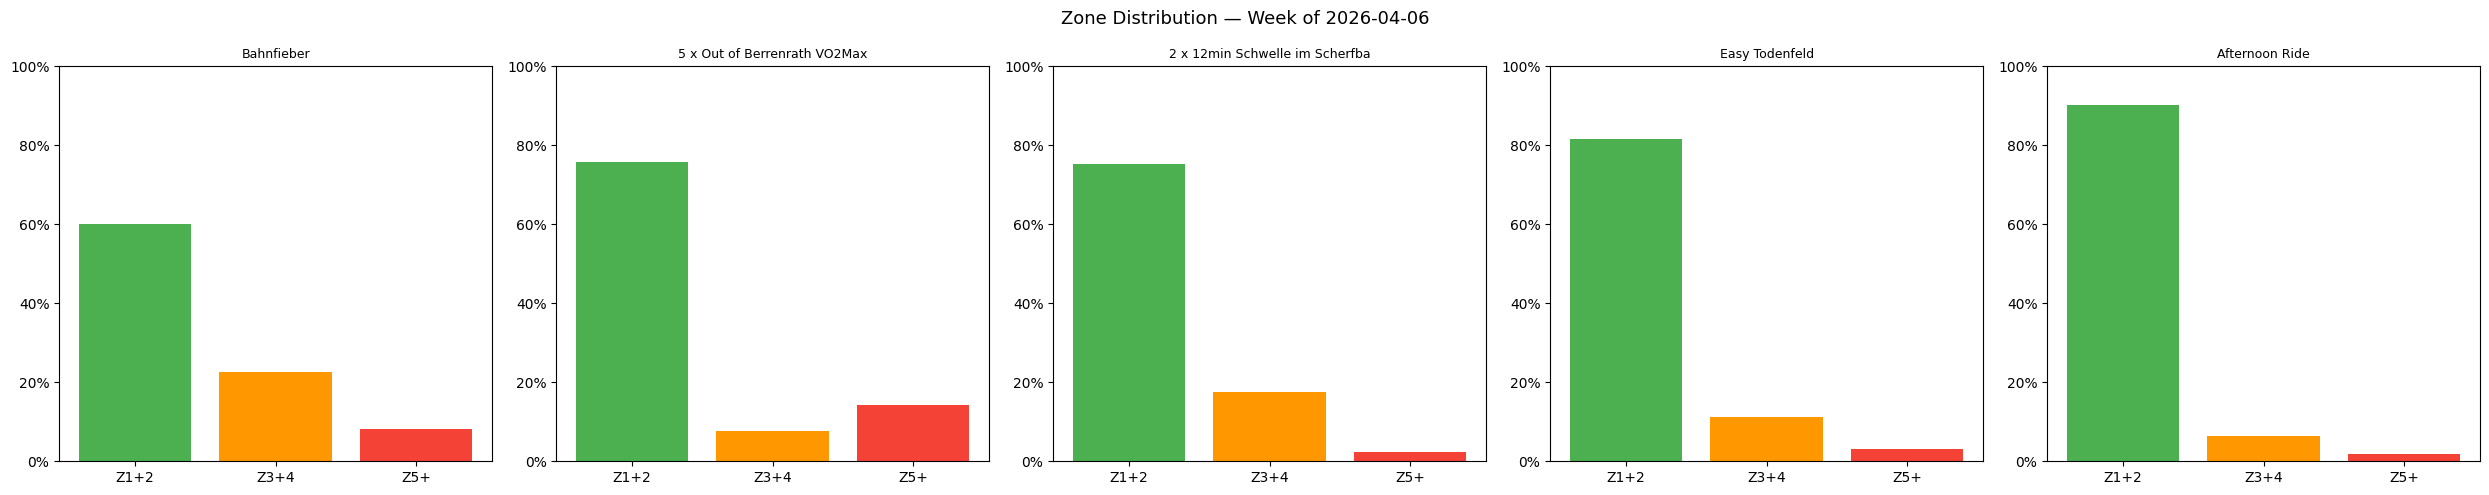

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

zone_df = df[["name", "z1_z2_pct", "z3_z4_pct", "z5_plus_pct"]].dropna()
n = len(zone_df)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Zone Distribution \u2014 Week of {data['week_starting']}", fontsize=13)

    for ax, row in zip(axes, zone_df.itertuples()):
        values = [row.z1_z2_pct, row.z3_z4_pct, row.z5_plus_pct]
        labels = ["Z1+2", "Z3+4", "Z5+"]
        colors = ["#4caf50", "#ff9800", "#f44336"]
        ax.bar(labels, values, color=colors)
        ax.set_title(row.name[:30], fontsize=9)
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(ticker.PercentFormatter())

    plt.tight_layout()
    plt.show()

## Fueling Analysis

In [6]:
fueling = data.get("fueling_analysis", {})
fa = fueling.get("activities", [])

if fa:
    df_fuel = pd.DataFrame(fa)
    fuel_cols = [
        "date", "name", "duration_hours", "fueling_status", "ride_type",
        "carbs_per_hour", "carbs_classification", "fueling_ratio",
        "ratio_classification", "is_long_ride", "flags",
    ]
    fuel_cols = [c for c in fuel_cols if c in df_fuel.columns]
    display(df_fuel[fuel_cols])

    fs = fueling.get("weekly_summary", {})
    print(f"\nLong rides:           {fs.get('number_of_long_rides')}")
    print(f"Avg carbs/h:          {fs.get('avg_carbs_per_hour')} g")
    print(f"Avg fueling ratio:    {fs.get('avg_fueling_ratio')}")
    print(f"Underfueled sessions: {fs.get('number_of_underfueled_sessions')}")

    print("\nRecommendations:")
    for r in fueling.get("recommendations", []):
        print(f"  * {r}")

,date,name,duration_hours,fueling_status,ride_type,carbs_per_hour,carbs_classification,fueling_ratio,ratio_classification,is_long_ride,flags
0,2026-03-30,Bahnfieber,0.61,no fueling needed,endurance_with_sprint,0.0,not required,0.00,not applicable,False,[]
1,2026-04-01,5 x Out of Berrenrath VO2Max,1.59,fueling optional,vo2,0.0,optional,0.00,optional,False,[]
2,2026-04-03,2 x 12min Schwelle im Scherfbachtal,2.51,fueling required,threshold,19.9,very low,0.14,severe deficit,False,[]
3,2026-04-06,Easy Todenfeld,3.55,fueling required,long_ride,28.2,very low,0.23,severe deficit,True,"[underfueled long ride, decoupling likely caus..."
4,2026-04-07,Afternoon Ride,1.87,fueling optional,endurance,0.0,optional,0.00,optional,False,[]



Long rides:           1
Avg carbs/h:          28.2 g
Avg fueling ratio:    0.23
Underfueled sessions: 1

Recommendations:
  * Increase fueling on long rides — target at least 60 g/h.
  * Target 80–90 g/h on long rides (> 2 h).
  * Fueling likely limiting aerobic durability — address carbohydrate intake on longer sessions.
  * Short rides do not require fueling — focus on long sessions.
